# Petstore Sales Forecasting Using ARIMA

## Business Problem Statement 

As part of business operations and analytics initiatives at Zigly Petcare, Management required a data-driven approach to forecast monthly revenue trends across pet care products and services. 

The objective of this project is to analyze historical sales data from January 2021 to March 2024 and develop forecasting models capable of supporting:
- Revenue planning
- Inventory optimization
- Demand forecasting
- Seasonal trend analysis
- Quarterly business planning
- Marketing campaign planning

Time-series forecasting techniques including Moving Average and ARIMA were implemented to predict future monthly revenue trends over a 12-month horizon.

----

## Tools & Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- Scikit-learn

---

## Business Objective

The final output of this project is intended to help business stakeholders make data-driven decisions related to:
- Inventory management
- Resource allocation
- Revenue target planning
- Seasonal demand management
- Operational efficiency

In [1]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
# loading dataset

df = pd.read_excel("petstore_sales_forecasting_dataset.xlsx")
df.head()

,Order_Date,Product_Category,Revenue_INR,Quantity,Region,Sales_Channel,Payment_Mode,Month,Quarter,Year,Month_Name
0,2021-01-01,Dog Food,1749.84,6,Noida,Online,Card,2021-01,1,2021,Jan
1,2021-01-01,Cat Food,1489.48,6,Mumbai,Online,Wallet,2021-01,1,2021,Jan
2,2021-01-01,Dog Food,1768.24,1,Gurugram,Online,UPI,2021-01,1,2021,Jan
3,2021-01-01,Accessories,1484.88,6,Mumbai,Store,Card,2021-01,1,2021,Jan
4,2021-01-01,Vet Services,6740.84,3,Delhi NCR,Online,Wallet,2021-01,1,2021,Jan


In [3]:
print(f"Dataset Shape: {df.shape}")

print("\nColumns:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (38797, 11)

Columns:
 Index(['Order_Date', 'Product_Category', 'Revenue_INR', 'Quantity', 'Region',
       'Sales_Channel', 'Payment_Mode', 'Month', 'Quarter', 'Year',
       'Month_Name'],
      dtype='str')

Data Types:

Order_Date          datetime64[us]
Product_Category               str
Revenue_INR                float64
Quantity                     int64
Region                         str
Sales_Channel                  str
Payment_Mode                   str
Month                          str
Quarter                      int64
Year                         int64
Month_Name                     str
dtype: object


In [4]:
# Basic data cleaning

# Checking missing values
df.isnull().sum()

Order_Date          0
Product_Category    0
Revenue_INR         0
Quantity            0
Region              0
Sales_Channel       0
Payment_Mode        0
Month               0
Quarter             0
Year                0
Month_Name          0
dtype: int64

In [5]:
# Checking min and max dates

print("Start Date:", df['Order_Date'].min())
print("End Date:", df['Order_Date'].max())

Start Date: 2021-01-01 00:00:00
End Date: 2024-03-31 00:00:00


In [6]:
# Creating monthly revenue aggregation

monthly_sales = df.groupby('Month'
)['Revenue_INR'].sum()

monthly_sales = monthly_sales.reset_index()

monthly_sales.head()

,Month,Revenue_INR
0,2021-01,3676853.18
1,2021-02,3068594.61
2,2021-03,3994226.50
3,2021-04,3862444.50
4,2021-05,4777791.57


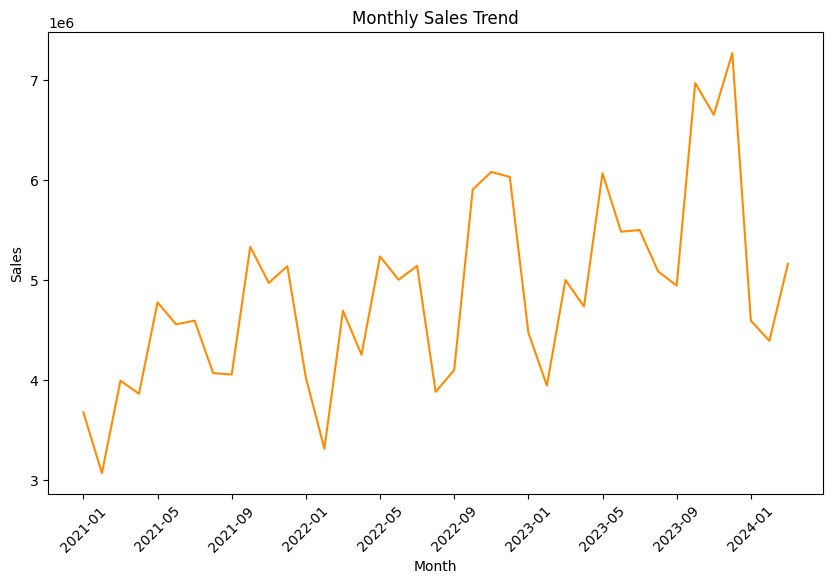

In [7]:
# plotting monthly sales trend
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.Month, monthly_sales.Revenue_INR, color = "#FF8C00")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout
plt.xticks(ticks=range(0, len(monthly_sales), 4), rotation = 45)
plt.show()

### Observations by visualizing the sales trend :
    - There is overall growth in the revenue. As we can see, the revenue falls between 3 and 4 million at the start of 2021. And towards the end of 2023, it is coming somewhere between 6-7 million. 
    - Seasonality is present. We can see the sales going high towards the end of each year. And we can see a dip in the sales in the starting months of each year. 
    - The variance/fluctuations become larger as the revenue grows. 

## ---------------------------------------------------------------------------

### Moving Average Analysis

In [8]:
print(monthly_sales.head(2))                   ## Month is already an index. 

     Month  Revenue_INR
0  2021-01   3676853.18
1  2021-02   3068594.61


In [9]:
# Calculating Moving Average 
Moving_Avg = monthly_sales['Revenue_INR'].rolling(window=3).mean()

# Calculating Moving_std
moving_std = monthly_sales['Revenue_INR'].rolling(window=3).std()

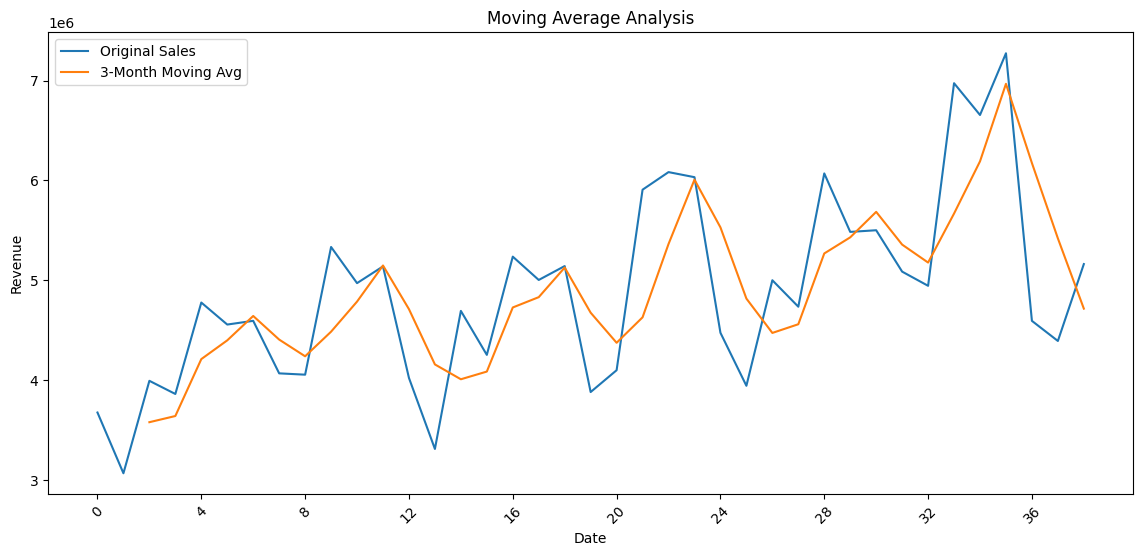

In [10]:
# Visualize moving average. 
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.Revenue_INR, label = 'Original Sales')
plt.plot(monthly_sales.index, Moving_Avg, label = '3-Month Moving Avg')
plt.title("Moving Average Analysis")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(ticks=range(0, len(monthly_sales), 4), rotation = 45)
plt.legend()
plt.show()

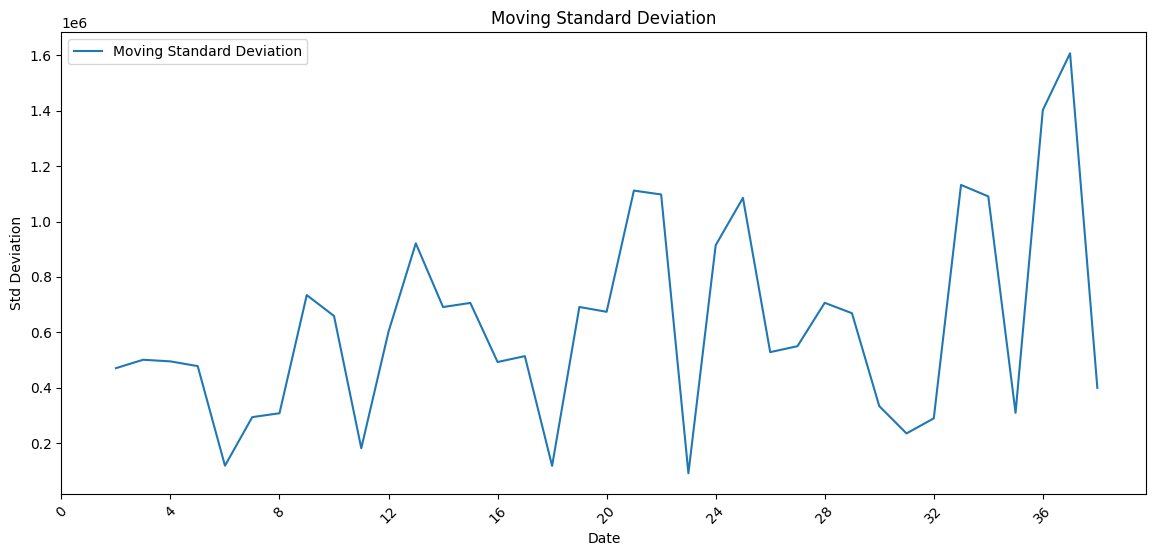

In [11]:
# Visualize moving std. 
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, moving_std, label = 'Moving Standard Deviation')
plt.title("Moving Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Std Deviation")
plt.xticks(ticks=range(0, len(monthly_sales), 4), rotation = 45)
plt.legend()
plt.show()

## ADF Test

In [12]:
result = adfuller(monthly_sales['Revenue_INR'])

print("ADF Staistics:", result[0])
print("p-value:", result[1])

## Since p-value is more than 0.05, we fail to reject the null hypothesis, which means the data is non-stationary.

ADF Staistics: 0.14124326274585616
p-value: 0.9687667386474628


### Make Series Stationary

#### Differencing

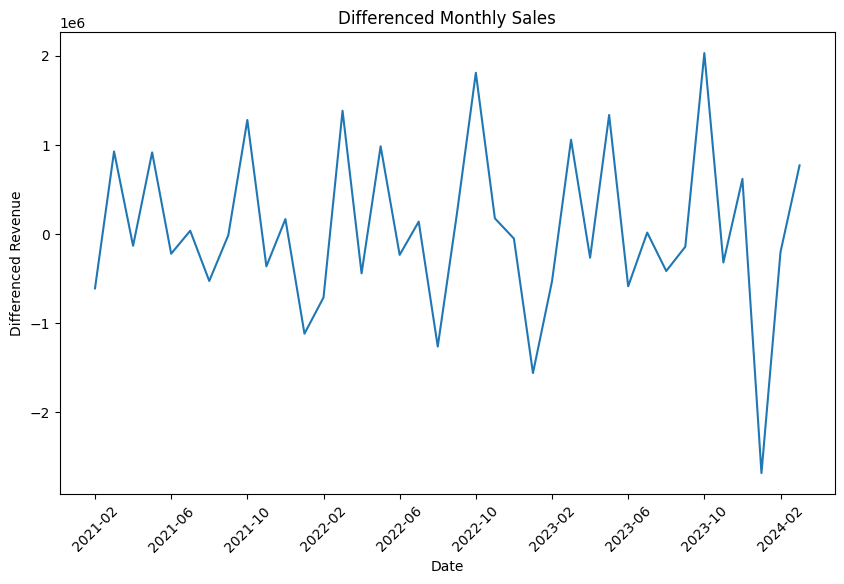

In [13]:
monthly_sales.set_index('Month', inplace = True)
monthly_sales_diff = monthly_sales.diff().dropna()

# visualize differenced data
plt.figure(figsize=(10,6))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Revenue")
plt.xticks(ticks=range(0, len(monthly_sales_diff), 4), rotation = 45)
plt.show()

# So, we can see that the differenced data is more stationary than the original data.
# We can perform ADF test on differenced data to confirm this.

In [14]:
# Again performing ADF test on differenced data
result = adfuller(monthly_sales_diff)

print("ADF Statistics:", result[0])
print("p-value:", result[1])

ADF Statistics: -7.055472996166497
p-value: 5.38941950686538e-10


In [15]:
print(result[1] < 0.05)

# After applying first-order differencing, the p-value dropped below 0.05, confirming stationarity.
# Therefore, we got d = 1 for the ARIMA model.

True


## PACF plot

<Figure size 1000x500 with 0 Axes>

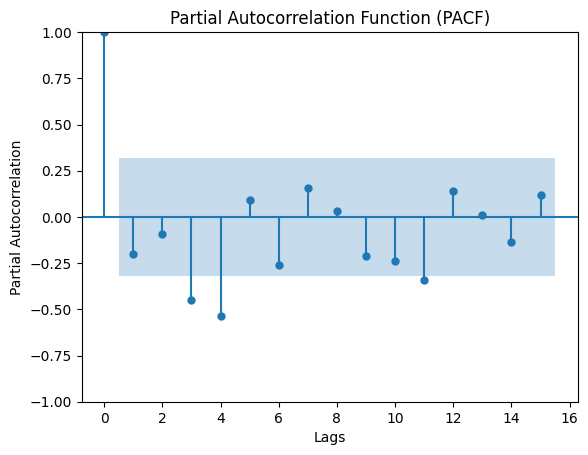

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))
plot_pacf(monthly_sales_diff, lags = 15)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lags")
plt.ylabel("Partial Autocorrelation")
plt.show()

<Figure size 1000x500 with 0 Axes>

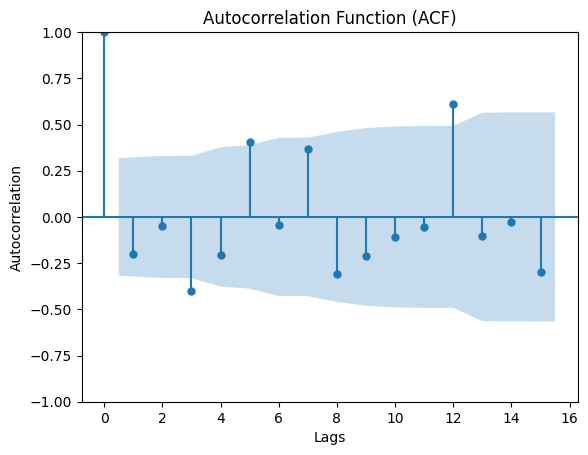

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10,5))
plot_acf(monthly_sales_diff, lags = 15)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

## Train Test Split

In [18]:
train_data = monthly_sales[:-6]
test_data = monthly_sales[-6:]


## Building ARIMA model

In [19]:
from statsmodels.tsa.arima.model import ARIMA
arima_orders = [(1,1,1), (2,1,1), (3,1,1), (3,1,2), (4,1,1)]
results = []

for order in arima_orders:
    model_arima = ARIMA(train_data, order=order)
    model_fit = model_arima.fit()

    prediction = model_fit.predict(
        start = len(train_data),    
        end = len(train_data) + len(test_data) - 1,
        dynamic = False)
    
    mae = mean_absolute_error(test_data, prediction)
    rmse = np.sqrt(mean_squared_error(test_data, prediction))

    results.append([order, model_fit.aic, model_fit.bic, mae, rmse])

In [20]:
results_df = pd.DataFrame(results, columns=['Order', 'AIC', 'BIC', 'MAE', 'RMSE']).sort_values(by='RMSE')
print(results_df)


       Order         AIC         BIC           MAE          RMSE
4  (4, 1, 1)  966.168841  974.963256  1.092151e+06  1.286619e+06
3  (3, 1, 2)  964.428165  973.222580  1.090814e+06  1.288384e+06
2  (3, 1, 1)  963.666227  970.994906  1.153933e+06  1.375605e+06
0  (1, 1, 1)  963.888101  968.285309  1.204013e+06  1.479253e+06
1  (2, 1, 1)  966.323305  972.186249  1.206327e+06  1.483586e+06


In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
results_sarima = []
seasonal_orders = [(1,0,1,12), (1,1,1,12), (0,1,1,12), (1,1,0,12)]
for order in arima_orders:
    for seasonal_order in seasonal_orders:
        model_sarima = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        model_sarima_fit = model_sarima.fit()
        prediction_sarima = model_sarima_fit.predict(
        start = len(train_data),    
        end = len(train_data) + len(test_data) - 1,
        dynamic = False)
        mae = mean_absolute_error(test_data, prediction_sarima)
        rmse = np.sqrt(mean_squared_error(test_data, prediction_sarima))

        results_sarima.append([order, seasonal_order, model_sarima_fit.aic, model_sarima_fit.bic, mae, rmse])

In [22]:
results_sarima_df = pd.DataFrame(results_sarima, columns=['Order', 'seasonal_order', 'AIC', 'BIC', 'MAE', 'RMSE']).sort_values(by='RMSE')
print(results_sarima_df)

        Order seasonal_order         AIC         BIC           MAE  \
15  (3, 1, 2)  (1, 1, 0, 12)  582.170772  589.140898  4.301502e+05   
3   (1, 1, 1)  (1, 1, 0, 12)  575.905204  579.888133  4.659046e+05   
11  (3, 1, 1)  (1, 1, 0, 12)  578.080869  584.055262  4.699998e+05   
19  (4, 1, 1)  (1, 1, 0, 12)  580.200225  587.170351  4.814999e+05   
14  (3, 1, 2)  (0, 1, 1, 12)  572.935747  579.905873  4.559870e+05   
18  (4, 1, 1)  (0, 1, 1, 12)  580.810697  587.780823  4.853179e+05   
10  (3, 1, 1)  (0, 1, 1, 12)  578.749332  584.723726  4.855418e+05   
6   (2, 1, 1)  (0, 1, 1, 12)  576.263022  581.241683  4.917694e+05   
7   (2, 1, 1)  (1, 1, 0, 12)  578.777631  583.756292  4.998945e+05   
2   (1, 1, 1)  (0, 1, 1, 12)  576.826932  580.809861  5.166862e+05   
17  (4, 1, 1)  (1, 1, 1, 12)  582.392307  590.358165  6.422912e+05   
9   (3, 1, 1)  (1, 1, 1, 12)  580.319830  587.289956  6.460561e+05   
5   (2, 1, 1)  (1, 1, 1, 12)  577.391805  583.366199  6.803274e+05   
1   (1, 1, 1)  (1, 1

## Several ARIMA and SARIMA configurations were evaluated using AIC, MAE, and RMSE metrics.

The SARIMA(3,1,2)(1,1,0,12) model delivered the lowest forecasting error with:

• MAE = ₹430,150
• RMSE = ₹475,086

The model significantly outperformed standard ARIMA models by effectively capturing annual seasonal patterns present in the sales data.

## Therefore, SARIMA(3,1,2)(1,1,0,12) was selected as the final forecasting model.

## ----------------------------------------------------

## Retrain Final Model
Use all data

In [23]:
final_model = SARIMAX(
    monthly_sales,
    order=(3,1,2),
    seasonal_order=(1,1,0,12)
)

final_model_fit = final_model.fit()

## Generate 12 month Forecast

In [24]:
forecast = final_model_fit.predict(
    start = len(monthly_sales),    
    end = len(monthly_sales) + 11
)
print("12-Month Sales Forecast:")
forecast

12-Month Sales Forecast:


2024-04-01    4.942992e+06
2024-05-01    6.395460e+06
2024-06-01    5.793943e+06
2024-07-01    5.724411e+06
2024-08-01    5.340493e+06
2024-09-01    5.219764e+06
2024-10-01    7.327492e+06
2024-11-01    6.941989e+06
2024-12-01    7.552657e+06
2025-01-01    4.773468e+06
2025-02-01    4.659361e+06
2025-03-01    5.430610e+06
Freq: MS, Name: predicted_mean, dtype: float64

In [25]:
forecast_df = pd.DataFrame({'Month': forecast.index, 'Forecasted_Sales': forecast.values})
forecast_df['Forecasted_Sales'] = forecast_df['Forecasted_Sales'].round(0).astype(int)
forecast_df.head()

,Month,Forecasted_Sales
0,2024-04-01,4942992
1,2024-05-01,6395460
2,2024-06-01,5793943
3,2024-07-01,5724411
4,2024-08-01,5340493


In [26]:
forecast_df['Month'] = pd.to_datetime(
    forecast_df['Month']
)

In [31]:
monthly_sales.index = pd.to_datetime(
    monthly_sales.index
)

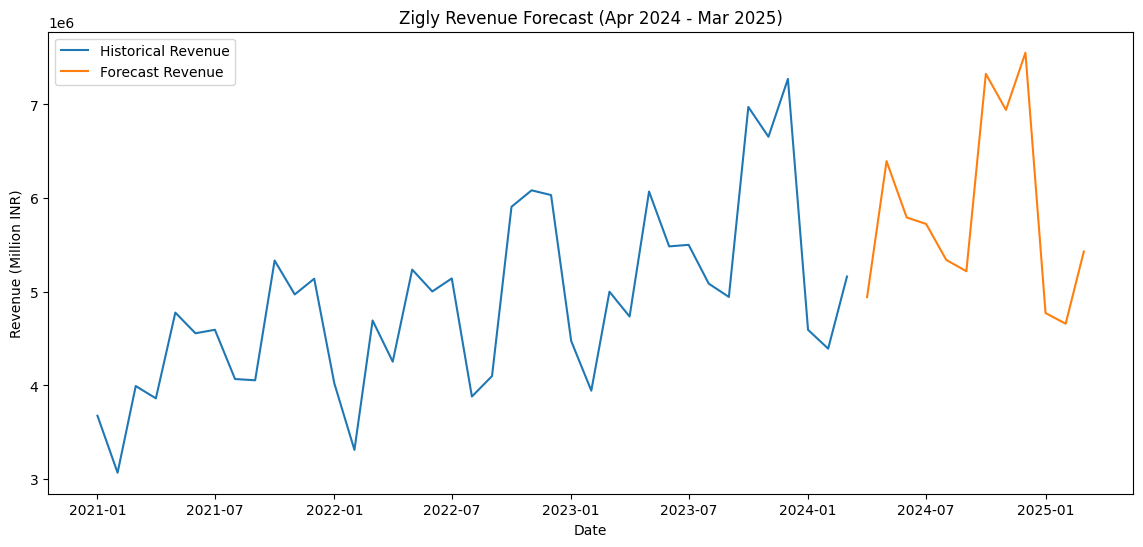

In [33]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales['Revenue_INR'],
    label='Historical Revenue'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast Revenue'
)

plt.title(
    'Zigly Revenue Forecast (Apr 2024 - Mar 2025)'
)

plt.xlabel('Date')
plt.ylabel('Revenue (Million INR)')
plt.legend()

plt.show()

## Business Recommendations

1. Inventory should be increased before Q4 due to seasonal demand spikes.

2. Marketing campaigns should be concentrated during periods showing forecasted growth.

3. Procurement planning should align with projected sales peaks.

4. Revenue is expected to continue growing over the next 12 months, indicating positive business expansion.